# Sarcina 2 — Analiza Datelor: Artrită Reumatoidă (150 observații)

Utilizând setul de date generat la Sarcina 1 (150 observații — pacienți cu Artrită Reumatoidă și grup de control), realizați o analiză descriptivă completă a variabilelor și construiți vizualizări multidimensionale, respectând principiile de claritate, minimalism și adecvare a tipului de grafic la natura datelor.

Pentru toate variabilele numerice calculați: media, mediana, abaterea standard, varianța, valorile minime și maxime, quartilele, asimetria și curtosis.

### Definițiile metricilor descriptive

- **Media (mean)** — suma tuturor valorilor împărțită la numărul de observații. Reprezintă valoarea centrală a distribuției.
- **Mediana (median)** — valoarea care împarte setul de date ordonat în două jumătăți egale. Este robustă la valori extreme (outliers).
- **Abaterea standard (standard deviation)** — măsoară dispersia valorilor în jurul mediei. O valoare mică indică date concentrate aproape de medie, una mare indică date împrăștiate.
- **Varianța (variance)** — pătratul abaterii standard. Cuantifică variabilitatea totală a datelor, dar este exprimată în unități pătratice.
- **Minimul (min)** — cea mai mică valoare observată în setul de date.
- **Maximul (max)** — cea mai mare valoare observată în setul de date.
- **Quartila 1 (Q1, 25%)** — valoarea sub care se află 25% din observații. Marchează granița inferioară a distribuției centrale.
- **Quartila 2 (Q2, 50%)** — identică cu mediana; 50% din valori sunt sub acest prag.
- **Quartila 3 (Q3, 75%)** — valoarea sub care se află 75% din observații. Marchează granița superioară a distribuției centrale.
- **Asimetria (skewness)** — măsoară simetria distribuției. Valoare 0 = distribuție simetrică; valoare pozitivă = coadă prelungită spre dreapta; valoare negativă = coadă prelungită spre stânga.
- **Curtosis (kurtosis)** — măsoară greutatea cozilor distribuției comparativ cu distribuția normală. Valoare > 0 (leptokurtică) = cozi mai grele și vârf mai ascuțit; valoare < 0 (platikurtică) = cozi mai ușoare și vârf mai plat.

In [ ]:
%pip install scipy --quiet

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import os

os.makedirs("figures", exist_ok=True)

df = pd.read_csv("output/Sarcina1_BazaDate_RA_150obs.csv")

numeric_cols = [
    'Varsta', 'BMI', 'CRP_mgL', 'ESR_mmh', 'CDAI', 'SDAI',
    'DAS28_ESR', 'DAS28_CRP', 'RF_Titru', 'ACPA_Titru',
    'Proteina_CRP', 'IL6_Nivel', 'TNF_Nivel',
    'Homocysteine', 'Spermidine', 'Kynurenine'
]

descriptive = pd.DataFrame({
    "Media": df[numeric_cols].mean(),
    "Mediana": df[numeric_cols].median(),
    "Abaterea standard": df[numeric_cols].std(),
    "Varianța": df[numeric_cols].var(),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max(),
    "Q1 (25%)": df[numeric_cols].quantile(0.25),
    "Q2 (50%)": df[numeric_cols].quantile(0.50),
    "Q3 (75%)": df[numeric_cols].quantile(0.75),
    "Asimetria (skewness)": df[numeric_cols].skew(),
    "Curtosis (kurtosis)": df[numeric_cols].kurtosis(),
})

descriptive

,Media,Mediana,Abaterea standard,Varianța,Min,Max,Q1 (25%),Q2 (50%),Q3 (75%),Asimetria (skewness),Curtosis (kurtosis)
Varsta,57.062000,59.0000,10.332016,106.750560,32.000,76.000,49.25000,59.0000,64.75000,-0.410088,-0.479542
BMI,29.206133,28.2000,7.327250,53.688592,18.000,58.200,24.42000,28.2000,32.52500,1.158078,2.338438
CRP_mgL,9.399725,2.9000,17.606179,309.977547,0.100,113.500,2.90000,2.9000,8.20000,3.942532,17.379958
ESR_mmh,15.287963,10.0000,15.118539,228.570228,0.000,73.000,5.00000,10.0000,21.72500,1.582558,2.369799
CDAI,14.191011,9.4000,14.593621,212.973782,0.000,66.800,3.10000,9.4000,19.00000,1.397349,1.734516
SDAI,25.787640,14.8000,28.921500,836.453141,0.500,153.000,6.20000,14.8000,33.70000,2.104273,5.085140
DAS28_ESR,3.487582,3.6500,1.757103,3.087410,0.210,7.990,1.96000,3.6500,4.79000,0.250861,-0.668081
DAS28_CRP,3.479892,3.2900,1.530228,2.341597,0.500,7.490,2.23000,3.2900,4.77000,0.439815,-0.516426
RF_Titru,62.884722,18.5000,119.404785,14257.502721,5.000,803.000,14.90000,18.5000,59.75000,4.493402,23.642923
ACPA_Titru,89.819481,15.5000,104.009843,10818.047379,1.500,251.000,15.50000,15.5000,251.00000,0.780098,-1.238622


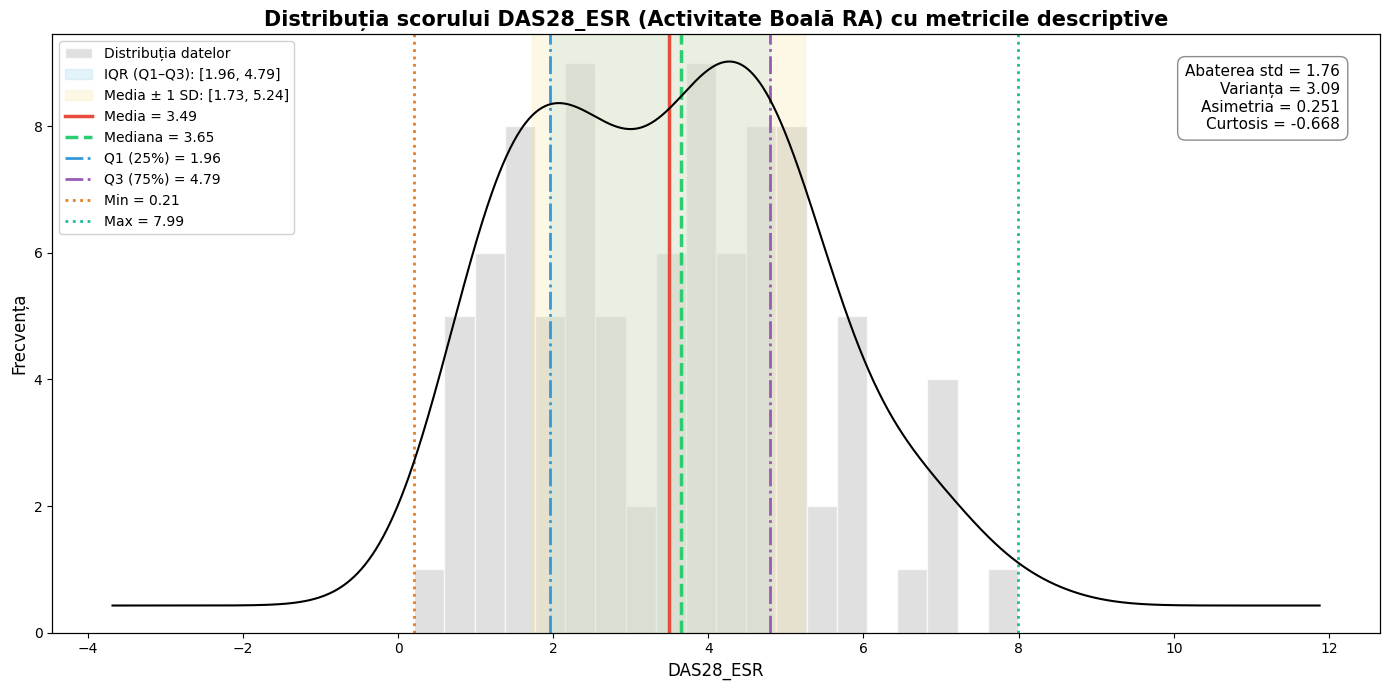

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

col = "DAS28_ESR"
data = df[col].dropna()

mean_val = data.mean()
median_val = data.median()
std_val = data.std()
min_val = data.min()
max_val = data.max()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
skew_val = data.skew()
kurt_val = data.kurtosis()

fig, ax = plt.subplots(figsize=(14, 7))

ax.hist(data, bins=20, color="#d3d3d3", edgecolor="white", alpha=0.7, label="Distribuția datelor")
ax2 = ax.twinx()
data.plot.kde(ax=ax2, color="black", linewidth=1.5, label="KDE")
ax2.set_yticks([])
ax2.set_ylabel("")

ax.axvspan(q1, q3, color="#a8d8ea", alpha=0.3, label=f"IQR (Q1\u2013Q3): [{q1:.2f}, {q3:.2f}]")
ax.axvspan(mean_val - std_val, mean_val + std_val, color="#f9e79f", alpha=0.25,
           label=f"Media \u00b1 1 SD: [{mean_val - std_val:.2f}, {mean_val + std_val:.2f}]")

ax.axvline(mean_val, color="#e74c3c", linewidth=2.5, linestyle="-",
           label=f"Media = {mean_val:.2f}")
ax.axvline(median_val, color="#2ecc71", linewidth=2.5, linestyle="--",
           label=f"Mediana = {median_val:.2f}")
ax.axvline(q1, color="#3498db", linewidth=2, linestyle="-.",
           label=f"Q1 (25%) = {q1:.2f}")
ax.axvline(q3, color="#9b59b6", linewidth=2, linestyle="-.",
           label=f"Q3 (75%) = {q3:.2f}")
ax.axvline(min_val, color="#e67e22", linewidth=2, linestyle=":",
           label=f"Min = {min_val:.2f}")
ax.axvline(max_val, color="#1abc9c", linewidth=2, linestyle=":",
           label=f"Max = {max_val:.2f}")

textstr = (f"Abaterea std = {std_val:.2f}\n"
           f"Varian\u021ba = {std_val**2:.2f}\n"
           f"Asimetria = {skew_val:.3f}\n"
           f"Curtosis = {kurt_val:.3f}")
props = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9)
ax.text(0.97, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment="top", horizontalalignment="right", bbox=props)

ax.set_title(f"Distribu\u021bia scorului {col} (Activitate Boal\u0103 RA) cu metricile descriptive",
             fontsize=15, fontweight="bold")
ax.set_xlabel(col, fontsize=12)
ax.set_ylabel("Frecven\u021ba", fontsize=12)
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig("figures/RA_DAS28_ESR_descriptive_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

Pentru variabilele categoriale determinați: frecvențele absolute, frecvențele relative și moda.

### Definițiile metricilor pentru variabile categoriale

- **Frecvența absolută** — numărul de observații din fiecare categorie. Arată câte ori apare fiecare valoare în setul de date.
- **Frecvența relativă** — proporția fiecărei categorii din totalul observațiilor (frecvența absolută / N). Exprimată ca procent, permite compararea între categorii indiferent de mărimea eșantionului.
- **Moda (mode)** — categoria cu cea mai mare frecvență absolută. Reprezintă valoarea cea mai frecventă din distribuție.

In [4]:
categorical_cols = [
    "Fumator", "ACPA_Pozitiv", "Sex_Feminin", "RF_Prezent",
    "CRP_Ridicat", "Boala_Activa", "Nivel_RF", "Nivel_ACPA",
    "Activitate_Boala", "Categorie_Varsta", "Grup_Studiu"
]

for col in categorical_cols:
    freq_abs = df[col].value_counts().sort_index()
    freq_rel = df[col].value_counts(normalize=True).sort_index() * 100
    moda = df[col].mode()[0]

    tabel = pd.DataFrame({
        "Frecven\u021ba absolut\u0103": freq_abs,
        "Frecven\u021ba relativ\u0103 (%)": freq_rel.round(2)
    })
    tabel.index.name = col

    print(f"{'='*50}")
    print(f"  {col}  |  Moda = {moda}")
    print(f"{'='*50}")
    print(tabel.to_string())
    print()

  Fumator  |  Moda = 0
         Frecvența absolută  Frecvența relativă (%)
Fumator                                            
0                       136                   90.67
1                        14                    9.33

  ACPA_Pozitiv  |  Moda = 0
              Frecvența absolută  Frecvența relativă (%)
ACPA_Pozitiv                                            
0                            105                    70.0
1                             45                    30.0

  Sex_Feminin  |  Moda = 1
             Frecvența absolută  Frecvența relativă (%)
Sex_Feminin                                            
0                            56                   37.33
1                            94                   62.67

  RF_Prezent  |  Moda = 1
            Frecvența absolută  Frecvența relativă (%)
RF_Prezent                                            
0                           50                   33.33
1                          100                   66.67

  CRP_Ridica

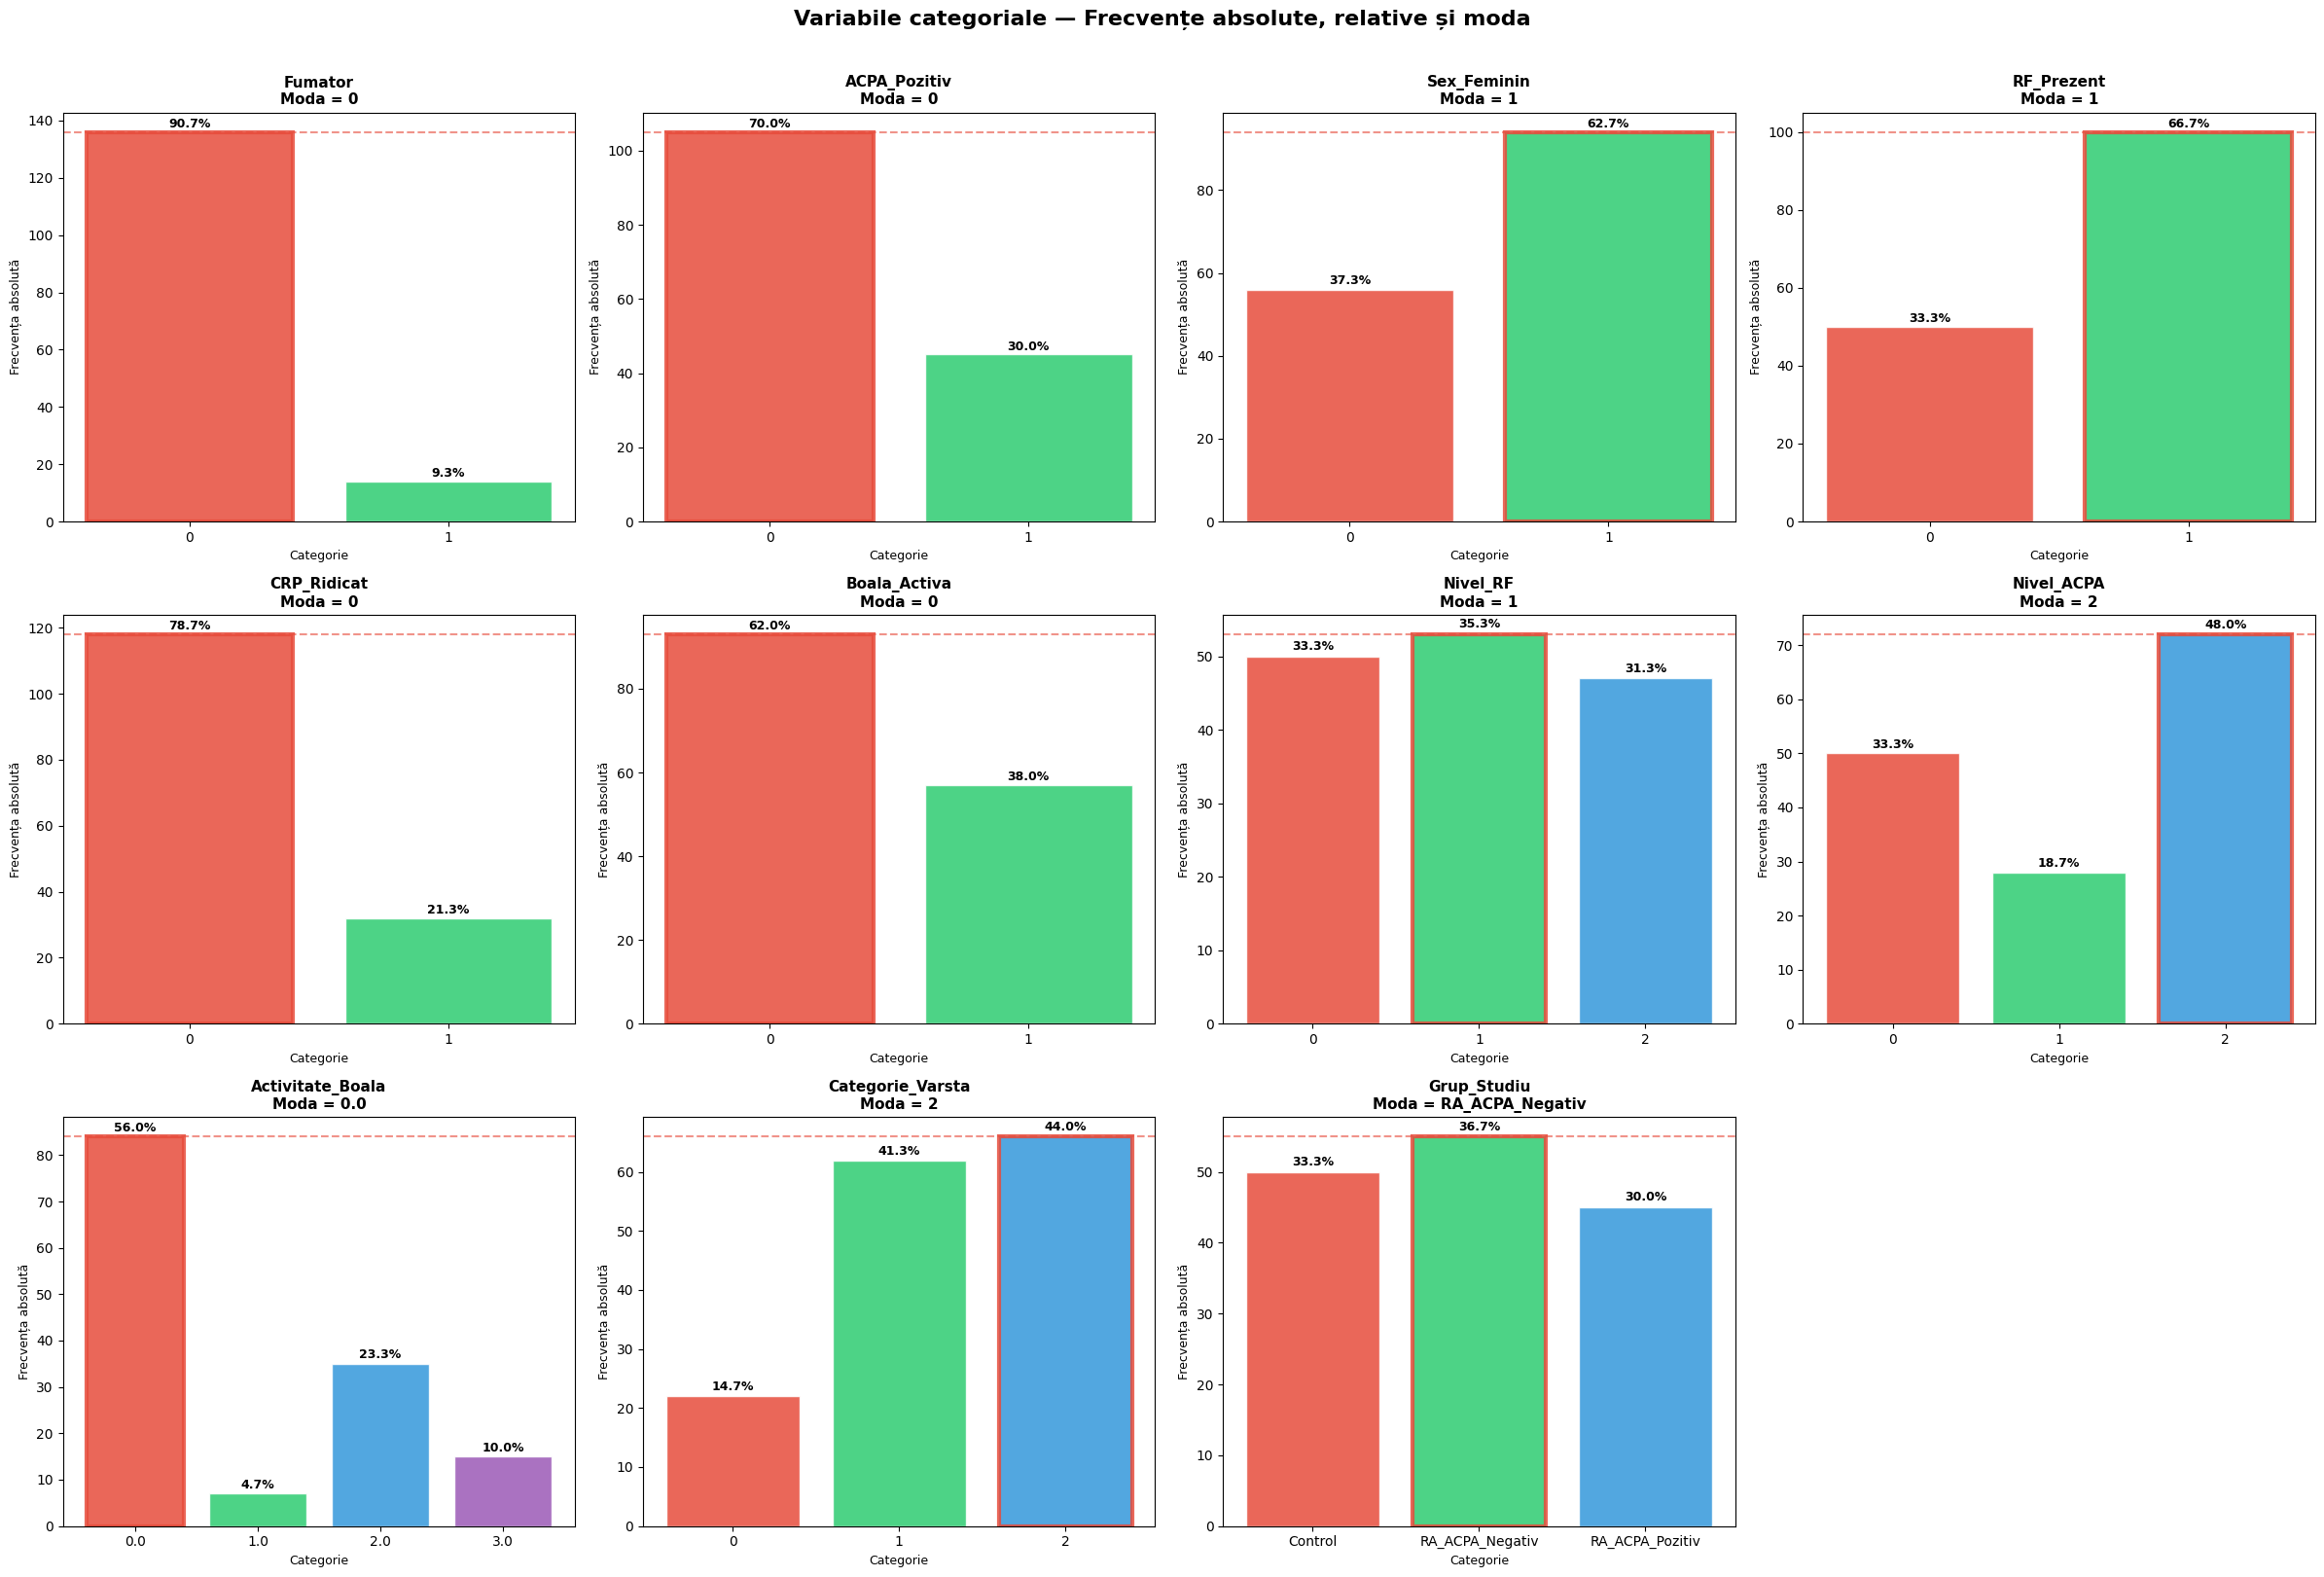

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(24, 16))
axes = axes.flatten()

colors_palette = ["#e74c3c", "#2ecc71", "#3498db", "#9b59b6", "#e67e22", "#1abc9c"]

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    freq_abs = df[col].value_counts().sort_index()
    freq_rel = (freq_abs / len(df) * 100)
    moda = df[col].mode()[0]

    bars = ax.bar(freq_abs.index.astype(str), freq_abs.values,
                  color=[colors_palette[i % len(colors_palette)] for i in range(len(freq_abs))],
                  edgecolor="white", alpha=0.85)

    moda_idx = list(freq_abs.index).index(moda)
    bars[moda_idx].set_edgecolor("#e74c3c")
    bars[moda_idx].set_linewidth(3)

    for bar, rel in zip(bars, freq_rel.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{rel:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.axhline(y=freq_abs[moda], color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.6)

    ax.set_title(f"{col}\nModa = {moda}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Categorie", fontsize=9)
    ax.set_ylabel("Frecven\u021ba absolut\u0103", fontsize=9)

for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Variabile categoriale \u2014 Frecven\u021be absolute, relative \u0219i moda",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/RA_categorical_variables_frequencies.png", dpi=150, bbox_inches="tight")
plt.show()

Vizualizarea datelor

## Grafice 1D (univariate)

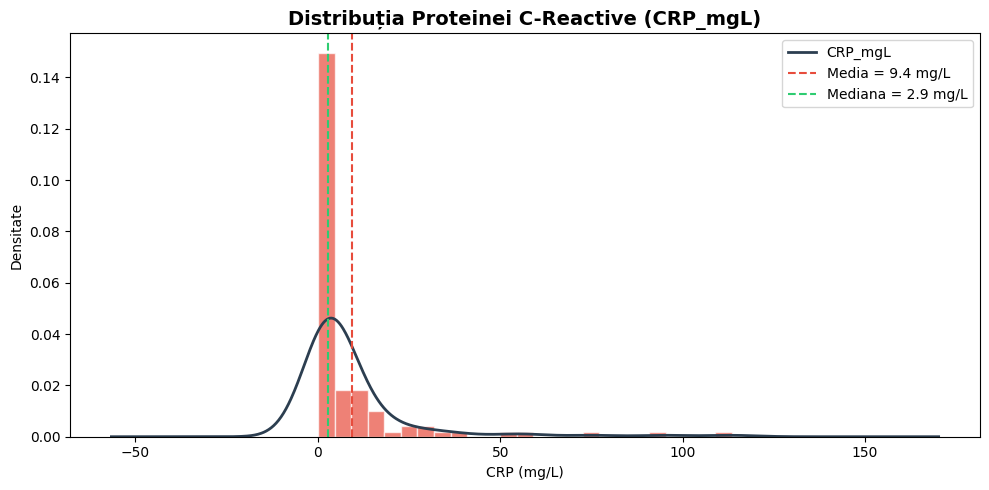

In [6]:
# 1D — Grafic 1: Histogramă + KDE pentru CRP (CRP_mgL)
data_crp = df["CRP_mgL"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(data_crp, bins=25, color="#e74c3c", edgecolor="white", alpha=0.7, density=True)
data_crp.plot.kde(ax=ax, color="#2c3e50", linewidth=2)
ax.axvline(data_crp.mean(), color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f'Media = {data_crp.mean():.1f} mg/L')
ax.axvline(data_crp.median(), color="#2ecc71", linestyle="--", linewidth=1.5,
           label=f'Mediana = {data_crp.median():.1f} mg/L')
ax.set_title("Distribu\u021bia Proteinei C-Reactive (CRP_mgL)", fontsize=14, fontweight="bold")
ax.set_xlabel("CRP (mg/L)")
ax.set_ylabel("Densitate")
ax.legend()
plt.tight_layout()
plt.savefig("figures/RA_1D_histogram_CRP.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretare — Histogramă CRP_mgL:**
- Distribuția CRP este puternic asimetrică pozitiv (coada dreaptă extinsă), tipică unui biomarker inflamator — majoritatea pacienților au valori mici, dar un subgrup cu boală activă severă prezintă valori extrem de ridicate (outlieri).
- Media este considerabil mai mare decât mediana, confirmând influența valorilor extreme (>50 mg/L) asupra tendinței centrale.
- Valorile sub 5 mg/L reprezintă pragul clinic normal; concentrarea masei distribuției în această zonă reflectă prezența grupului Control (sănătos) și a pacienților RA în remisie în eșantion.
- Vârful KDE are o cădere abruptă spre stânga și o coadă lungă spre dreapta — pattern caracteristic distribuțiilor log-normale comune în biomarkerii inflamatori.
- **Notă:** Variabila conține valori lipsă (NA) pentru unii pacienți din grupul Control, incluse în analiză prin eliminarea acestora (dropna).

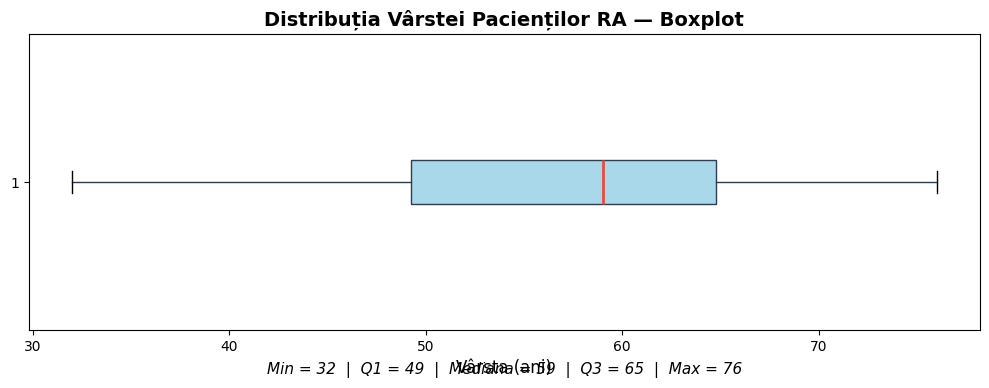

In [7]:
# 1D — Grafic 2: Boxplot pentru Varsta
fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(df["Varsta"].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor="#a8d8ea", edgecolor="#2c3e50"),
                medianprops=dict(color="#e74c3c", linewidth=2),
                whiskerprops=dict(color="#2c3e50"),
                flierprops=dict(marker="o", markerfacecolor="#e74c3c", markersize=6))
ax.set_xlabel("V\u00e2rsta (ani)", fontsize=12)
ax.set_title("Distribu\u021bia V\u00e2rstei Pacien\u021bilor RA \u2014 Boxplot", fontsize=14, fontweight="bold")

stats_text = (f"Min = {df['Varsta'].min():.0f}  |  Q1 = {df['Varsta'].quantile(0.25):.0f}  |  "
              f"Mediana = {df['Varsta'].median():.0f}  |  Q3 = {df['Varsta'].quantile(0.75):.0f}  |  Max = {df['Varsta'].max():.0f}")
ax.text(0.5, -0.15, stats_text, transform=ax.transAxes, ha="center", fontsize=11, style="italic")

plt.tight_layout()
plt.savefig("figures/RA_1D_boxplot_Varsta.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretare — Boxplot Vârsta:**
- Distribuția vârstei este relativ simetrică, cu mediana în jurul a 59 ani, reflectând vârful de incidență al artritei reumatoide la adulții de vârstă medie și înaintată.
- IQR-ul (Q1–Q3) acoperă aproximativ 15 ani (≈49–65 ani), sugerând o variabilitate moderată omogenă în cohortă.
- Nu se observă outlieri semnificativi, ceea ce indică un eșantion bine controlat demografic, fără extreme vârstnice sau tinere aberante.
- Intervalul complet (min–max ≈ 32–76 ani) confirmă că studiul include adulți activi și seniori, dar nu pacienți pediatrici sau vârstnici foarte înaintați.

## Grafice 2D (bivariate)

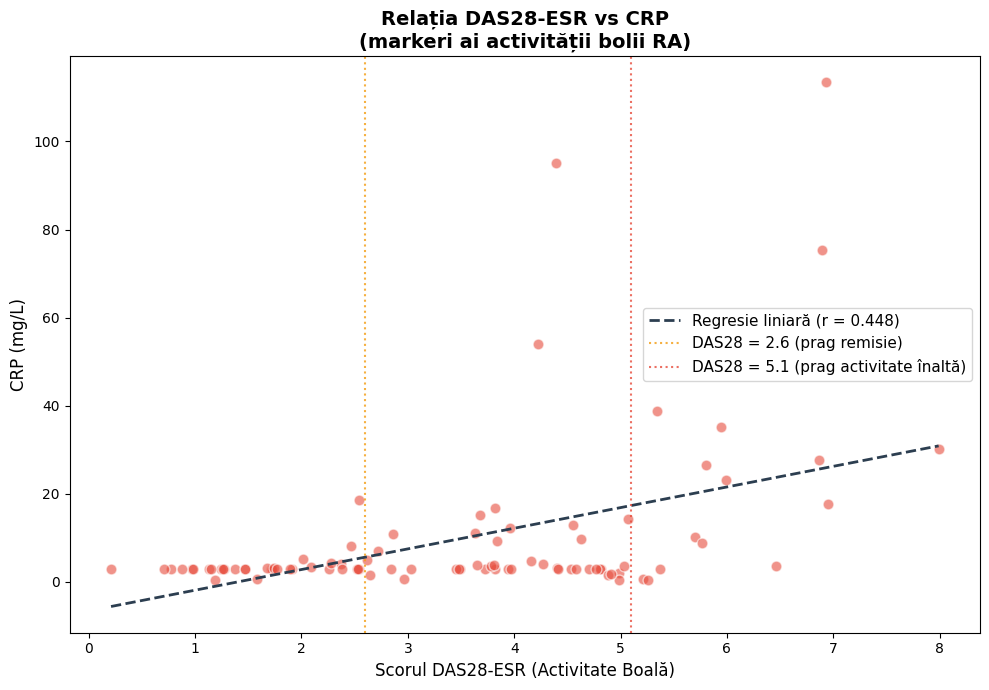

In [8]:
# 2D — Grafic 1: Scatter DAS28_ESR vs CRP_mgL cu linie de regresie
subset_2d = df[["DAS28_ESR", "CRP_mgL"]].dropna()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(subset_2d["DAS28_ESR"], subset_2d["CRP_mgL"],
           c="#e74c3c", alpha=0.6, edgecolors="white", s=60)

slope, intercept, r_value, _, _ = stats.linregress(subset_2d["DAS28_ESR"], subset_2d["CRP_mgL"])
x_line = np.linspace(subset_2d["DAS28_ESR"].min(), subset_2d["DAS28_ESR"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="#2c3e50", linewidth=2, linestyle="--",
        label=f"Regresie liniară (r = {r_value:.3f})")

ax.axvline(2.6, color="#f39c12", linewidth=1.5, linestyle=":", alpha=0.8, label="DAS28 = 2.6 (prag remisie)")
ax.axvline(5.1, color="#e74c3c", linewidth=1.5, linestyle=":", alpha=0.8, label="DAS28 = 5.1 (prag activitate înaltă)")

ax.set_xlabel("Scorul DAS28-ESR (Activitate Boală)", fontsize=12)
ax.set_ylabel("CRP (mg/L)", fontsize=12)
ax.set_title("Rela\u021bia DAS28-ESR vs CRP\n(markeri ai activit\u0103\u021bii bolii RA)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/RA_2D_scatter_DAS28_CRP.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretare — Scatter DAS28-ESR vs CRP:**
- Se observă o corelație pozitivă moderată între DAS28-ESR și CRP — pacienții cu activitate crescută a bolii (DAS28 ridicat) tind să prezinte și valori mai mari ale proteinei C-reactive, ambele reflectând inflamația sistemică.
- Coeficientul de corelație Pearson (r) cuantifică intensitatea relației liniare; o valoare r ≈ 0.4–0.6 este așteptată clinic, deoarece DAS28 include și componente non-CRP (număr articulații, evaluare globală).
- Liniile de prag clinice (DAS28 = 2.6 pentru remisie și 5.1 pentru activitate înaltă) evidențiază subgrupele: pacienții deasupra pragului 5.1 au și cele mai ridicate valori CRP.
- Pacienții sub DAS28 = 2.6 (remisie) au CRP preponderent sub 10 mg/L, confirmând controlul inflamației.
- **Dispersie:** variabilitatea CRP la DAS28 moderat (3–5) este mare, sugerând că același nivel de activitate clinică poate fi însoțit de răspunsuri inflamatorii biologice variate între pacienți.

/var/folders/fw/kfx5dll969l3zk0c0kkffkf80000gn/T/ipykernel_3542/3856051673.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Control\n(sănătos)", "RA ACPA-\nNegativ", "RA ACPA-\nPozitiv"], fontsize=11)


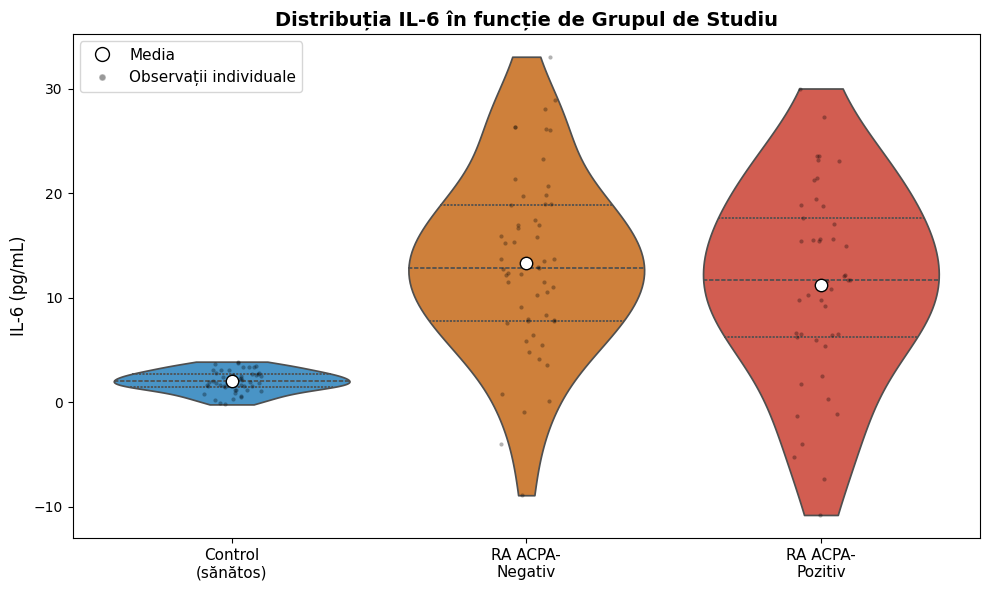

In [9]:
# 2D — Grafic 2: Violin plot IL6_Nivel pe Grup_Studiu
import seaborn as sns
from matplotlib.lines import Line2D

grup_order = ["Control", "RA_ACPA_Negativ", "RA_ACPA_Pozitiv"]
colors_grup = ["#3498db", "#e67e22", "#e74c3c"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x="Grup_Studiu", y="IL6_Nivel", order=grup_order,
               hue="Grup_Studiu", hue_order=grup_order,
               palette=colors_grup, inner="quartile", legend=False,
               cut=0, ax=ax)
sns.stripplot(data=df, x="Grup_Studiu", y="IL6_Nivel", order=grup_order,
              color="black", alpha=0.3, size=3, jitter=True, ax=ax)

for i, grp in enumerate(grup_order):
    mean_val = df[df["Grup_Studiu"] == grp]["IL6_Nivel"].mean()
    ax.scatter(i, mean_val, color="white", edgecolors="black", s=80, zorder=5)

ax.set_xticklabels(["Control\n(sănătos)", "RA ACPA-\nNegativ", "RA ACPA-\nPozitiv"], fontsize=11)
ax.set_ylabel("IL-6 (pg/mL)", fontsize=12)
ax.set_xlabel("")
ax.set_title("Distribu\u021bia IL-6 \u00een func\u021bie de Grupul de Studiu",
             fontsize=14, fontweight="bold")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
           markeredgecolor="black", markersize=10, label="Media"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black",
           markersize=5, alpha=0.4, label="Observa\u021bii individuale")
]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.savefig("figures/RA_2D_violin_IL6_Grup.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretare — Violin IL-6 vs Grup Studiu:**
- IL-6 este o citokină proinflamatorie cheie în patogeneza artritei reumatoide; distribuțiile sale diferă semnificativ între grupuri.
- Grupul Control prezintă valorile cele mai scăzute și mai concentrate de IL-6, cu un vârf KDE îngust la nivelul bazal, ceea ce reflectă absența bolii inflamatorii.
- Grupul RA_ACPA_Pozitiv are cea mai mare mediană și cea mai extinsă distribuție a IL-6, consistent cu faptul că seropozitivitatea ACPA se asociază cu o formă mai agresivă și mai inflamatorie de RA.
- Grupul RA_ACPA_Negativ se plasează intermediar, cu valori de IL-6 mai ridicate decât controlul, dar mai puțin dispersate decât RA_ACPA_Pozitiv.
- Prezența unor valori extreme (outlieri, puncte negre izolate) în grupele RA indică pacienți cu răspuns inflamator sistemic sever, candidați la terapii biologice anti-IL-6.

## Grafice 3D (trivariate)

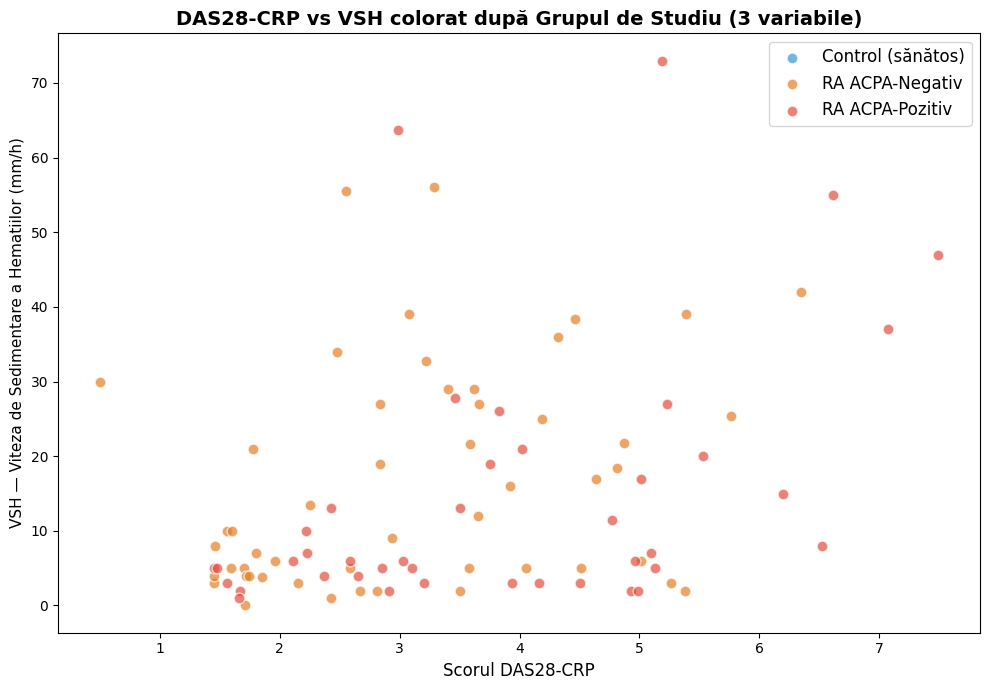

In [10]:
# 3D — Grafic 1: Scatter DAS28_CRP vs ESR_mmh, colorat după Grup_Studiu
# (x, y, culoare = 3 variabile)
subset_3d = df[["DAS28_CRP", "ESR_mmh", "Grup_Studiu"]].dropna()

fig, ax = plt.subplots(figsize=(10, 7))
colors_grup_map = {"Control": "#3498db", "RA_ACPA_Negativ": "#e67e22", "RA_ACPA_Pozitiv": "#e74c3c"}
labels_grup = {"Control": "Control (sănătos)",
               "RA_ACPA_Negativ": "RA ACPA-Negativ",
               "RA_ACPA_Pozitiv": "RA ACPA-Pozitiv"}

for grp in ["Control", "RA_ACPA_Negativ", "RA_ACPA_Pozitiv"]:
    mask = subset_3d["Grup_Studiu"] == grp
    ax.scatter(subset_3d.loc[mask, "DAS28_CRP"], subset_3d.loc[mask, "ESR_mmh"],
               c=colors_grup_map[grp], label=labels_grup[grp],
               alpha=0.7, edgecolors="white", s=60)

ax.set_xlabel("Scorul DAS28-CRP", fontsize=12)
ax.set_ylabel("VSH — Viteza de Sedimentare a Hematiilor (mm/h)", fontsize=11)
ax.set_title("DAS28-CRP vs VSH colorat dup\u0103 Grupul de Studiu (3 variabile)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/RA_3D_scatter_DAS28CRP_ESR_Grup.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretare — Scatter DAS28-CRP vs VSH colorat după Grup:**
- DAS28-CRP și VSH (ESR) sunt ambii indicatori consacrați ai activității inflamatorii în RA; corelația lor pozitivă confirmă validitatea internă a setului de date.
- Grupul Control (albastru) este compact concentrat în colțul stânga-jos (DAS28-CRP scăzut, VSH scăzut), confirmând absența inflamației la participanții sănătoși.
- Grupul RA_ACPA_Pozitiv (roșu) prezintă cea mai mare dispersie și valorile cele mai ridicate ale ambilor markeri, consistent cu forma mai severă de boală asociată seropozitivității.
- Grupul RA_ACPA_Negativ (portocaliu) se suprapune parțial cu RA_ACPA_Pozitiv, dar tinde să aibă valori moderat mai scăzute, reflectând un fenotip clinic ușor mai blând.
- **Separarea grupurilor** pe axa DAS28-CRP este mai clară decât pe axa VSH, sugerând că scorul compozit DAS28 discriminează mai bine activitatea bolii decât VSH singur.

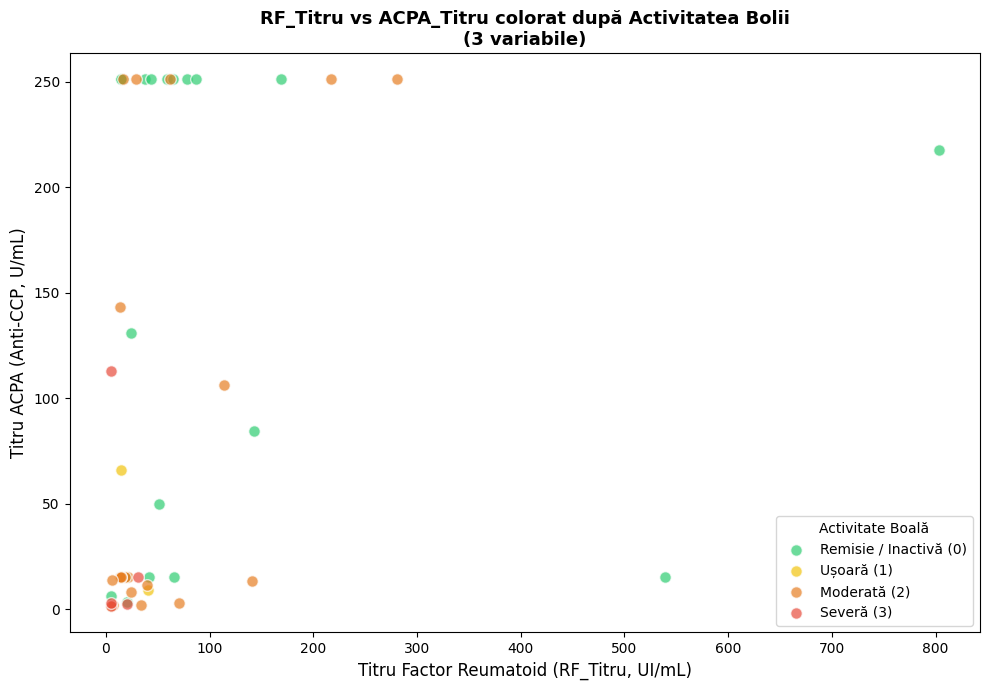

In [11]:
# 3D — Grafic 2: Scatter RF_Titru vs ACPA_Titru, colorat după Activitate_Boala
# (x, y, culoare = 3 variabile)
subset_rf = df[["RF_Titru", "ACPA_Titru", "Activitate_Boala"]].dropna()

fig, ax = plt.subplots(figsize=(10, 7))
activ_colors = {0.0: "#2ecc71", 1.0: "#f1c40f", 2.0: "#e67e22", 3.0: "#e74c3c"}
activ_labels = {0.0: "Remisie / Inactiv\u0103 (0)",
                1.0: "U\u0219oar\u0103 (1)",
                2.0: "Moderat\u0103 (2)",
                3.0: "Sever\u0103 (3)"}

for activ in [0.0, 1.0, 2.0, 3.0]:
    mask = subset_rf["Activitate_Boala"] == activ
    ax.scatter(subset_rf.loc[mask, "RF_Titru"], subset_rf.loc[mask, "ACPA_Titru"],
               c=activ_colors[activ], label=activ_labels[activ],
               alpha=0.7, edgecolors="white", s=70)

ax.set_xlabel("Titru Factor Reumatoid (RF_Titru, UI/mL)", fontsize=12)
ax.set_ylabel("Titru ACPA (Anti-CCP, U/mL)", fontsize=12)
ax.set_title("RF_Titru vs ACPA_Titru colorat dup\u0103 Activitatea Bolii\n(3 variabile)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, title="Activitate Boal\u0103")
plt.tight_layout()
plt.savefig("figures/RA_3D_scatter_RF_ACPA_Activitate.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretare — Scatter RF vs ACPA colorat după Activitatea Bolii:**
- Factorul reumatoid (RF) și anticorpii anti-peptide citrullinate (ACPA) sunt principalii markeri serologici de diagnostic ai RA; corelația lor pozitivă reflectă convergența proceselor autoimune.
- Pacienții cu boală activă severă (roșu, nivel 3) tind să se concentreze în zona titrelor ridicate atât pentru RF cât și pentru ACPA, confirmând că seropozitivitatea înaltă se asociază cu activitate mai agresivă.
- Pacienții în remisie/inactivi (verde, nivel 0) sunt preponderent în zona titrelor scăzute sau negativi serologic, deși există cazuri cu titru persistent ridicat în ciuda remisiei clinice — fenomen cunoscut în practică.
- Pacienții cu activitate ușoară (galben, nivel 1) au distribuție intermediară, în timp ce nivelul moderat (portocaliu, 2) prezintă cea mai mare dispersie, sugerând heterogenitate clinică la acest stadiu.
- **Concluzie:** titrele serologice RF și ACPA discriminează parțial activitatea bolii, dar nu sunt suficiente singure ca markeri ai severității — corelează mai bine cu diagnosticul decât cu activitatea curentă.

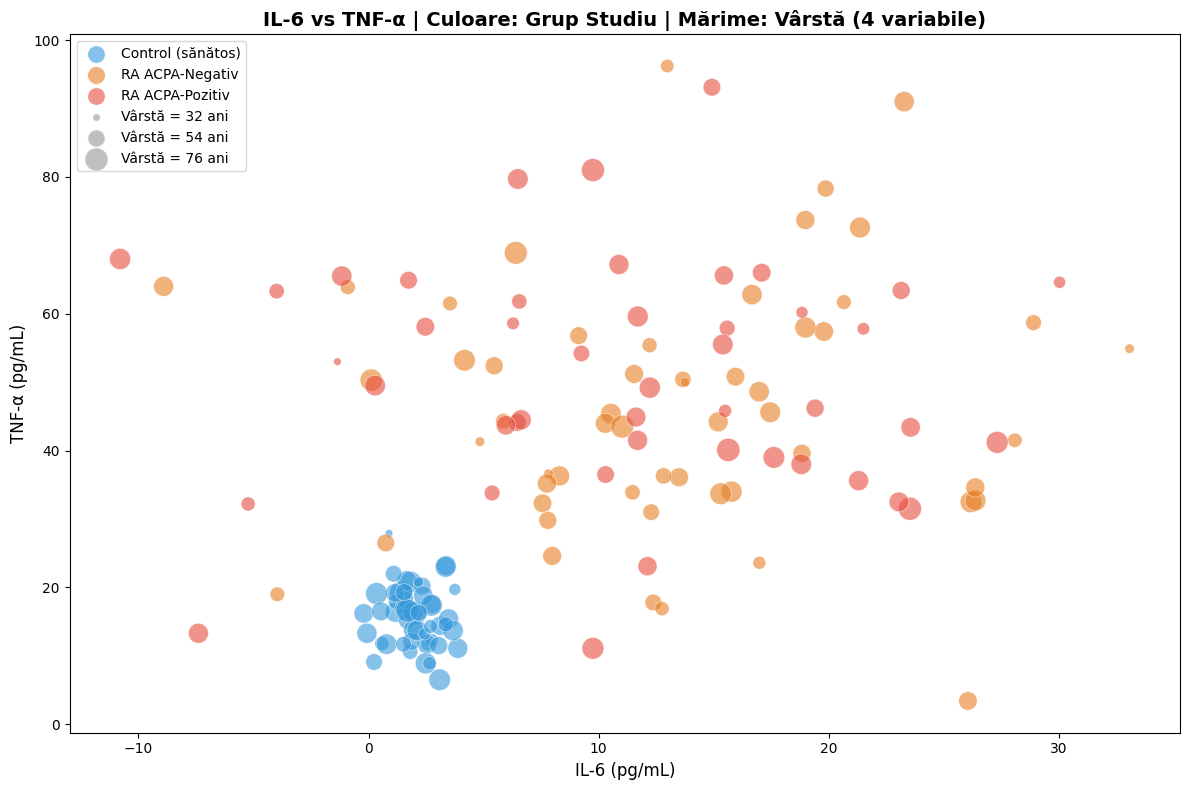

In [12]:
# 4D — Grafic 1: Scatter IL6_Nivel vs TNF_Nivel, culoare=Grup_Studiu, dimensiune=Varsta
# (x, y, culoare, mărime = 4 variabile)
fig, ax = plt.subplots(figsize=(12, 8))

size_min, size_max = 30, 280
age_norm = (df["Varsta"] - df["Varsta"].min()) / (df["Varsta"].max() - df["Varsta"].min())
sizes = size_min + age_norm * (size_max - size_min)

for grp in ["Control", "RA_ACPA_Negativ", "RA_ACPA_Pozitiv"]:
    mask = df["Grup_Studiu"] == grp
    ax.scatter(df.loc[mask, "IL6_Nivel"], df.loc[mask, "TNF_Nivel"],
               c=colors_grup_map[grp], s=sizes[mask], label=labels_grup[grp],
               alpha=0.6, edgecolors="white", linewidth=0.5)

for age_val, s_val in [(32, size_min), (54, (size_min + size_max) / 2), (76, size_max)]:
    ax.scatter([], [], c="gray", s=s_val, alpha=0.5, edgecolors="white",
               label=f"V\u00e2rst\u0103 = {age_val} ani")

ax.set_xlabel("IL-6 (pg/mL)", fontsize=12)
ax.set_ylabel("TNF-\u03b1 (pg/mL)", fontsize=12)
ax.set_title("IL-6 vs TNF-\u03b1 | Culoare: Grup Studiu | M\u0103rime: V\u00e2rst\u0103 (4 variabile)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig("figures/RA_4D_scatter_IL6_TNF_Grup_Varsta.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretare — 4D Scatter IL-6 vs TNF-α (culoare: Grup, mărime: Vârstă):**
- IL-6 și TNF-α sunt citokine proinflamatorii sinergice în RA; corelația lor pozitivă confirmă coproducția în cursul răspunsului inflamator articular.
- Pacienții RA (portocaliu și roșu) ocupă zone cu valori mai ridicate ale ambelor citokine față de Control (albastru), cu separare vizibilă între grupuri.
- Pacienții vârstnici (puncte mari) din grupul RA tind să prezinte niveluri mai ridicate de citokine, sugerând acumularea inflamației cronice în timp — efect combinat al îmbătrânirii imunologice și al duratei bolii.
- Grupul Control cu puncte mari (vârstnici sănătoși) are totuși citokine la niveluri bazale, confirmând că vârsta singură nu explică nivelurile citokine crescute.
- **Outlieri:** câțiva pacienți RA cu IL-6 și TNF-α simultan foarte ridicate reprezintă cazuri cu inflamație sistemică severă, candidați prioritari pentru terapie biologică.

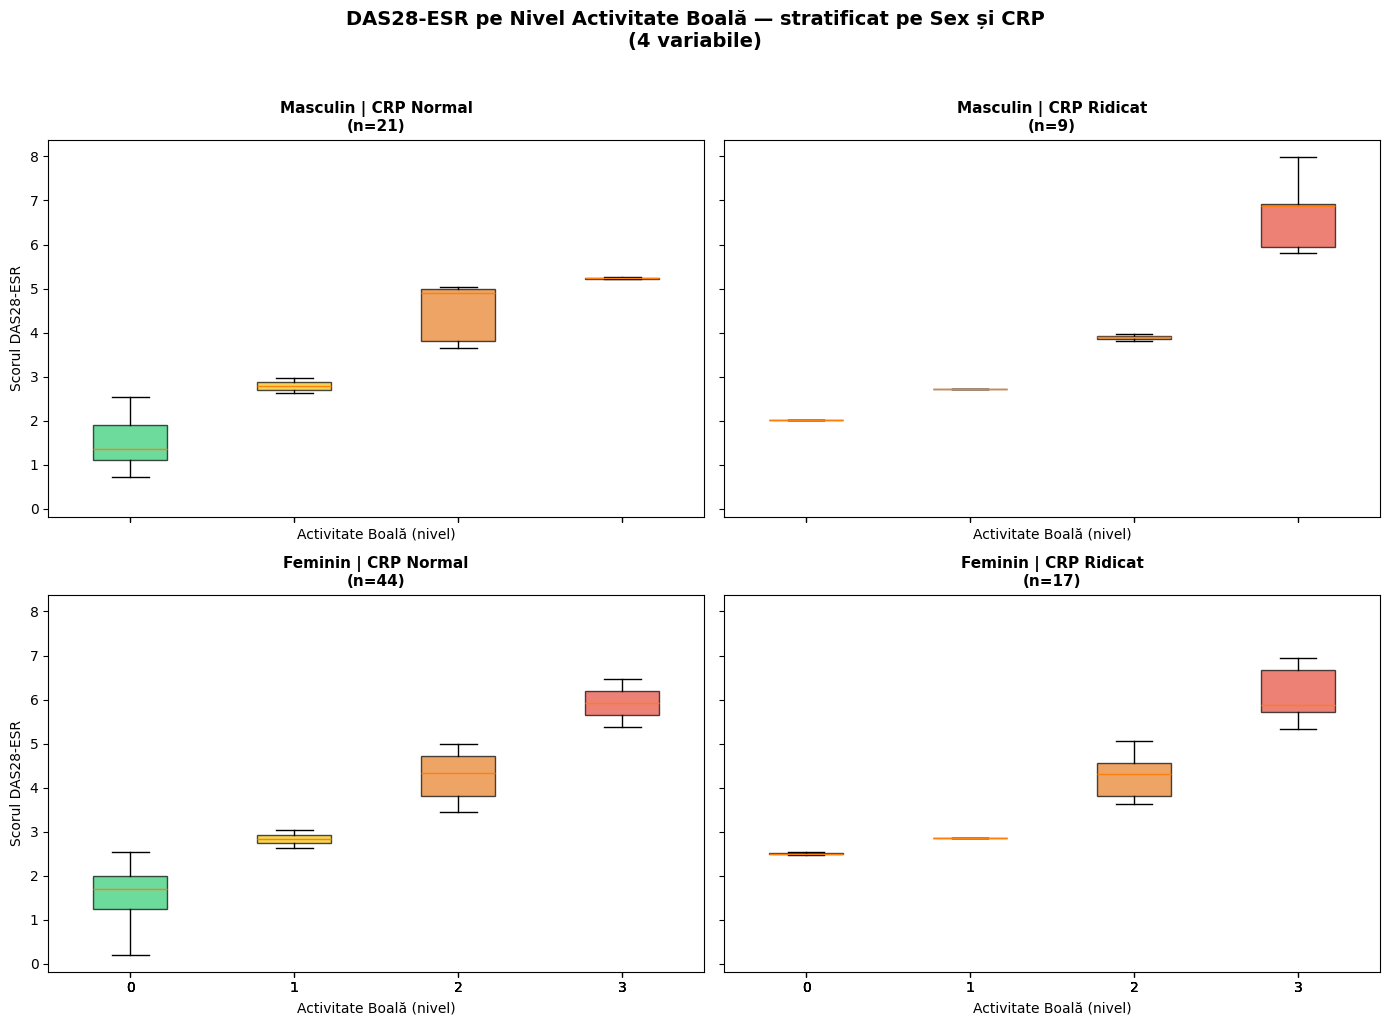

In [13]:
# 4D — Grafic 2: Boxplot DAS28_ESR pe Activitate_Boala, stratificat pe Sex_Feminin și CRP_Ridicat
# (variabile: DAS28_ESR, Activitate_Boala, Sex_Feminin, CRP_Ridicat = 4 variabile)
ra_df = df.dropna(subset=["DAS28_ESR"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True, sharex=True)

sex_labels = {0: "Masculin", 1: "Feminin"}
crp_labels = {0: "CRP Normal", 1: "CRP Ridicat"}
colors_box = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
activ_values = sorted(ra_df["Activitate_Boala"].dropna().unique())

for i, sex in enumerate([0, 1]):
    for j, crp_r in enumerate([0, 1]):
        ax = axes[i][j]
        subset = ra_df[(ra_df["Sex_Feminin"] == sex) & (ra_df["CRP_Ridicat"] == crp_r)]

        data_groups = []
        tick_labels = []
        box_colors = []
        for s_idx, s in enumerate(activ_values):
            vals = subset[subset["Activitate_Boala"] == s]["DAS28_ESR"].values
            if len(vals) > 0:
                data_groups.append(vals)
                tick_labels.append(str(int(s)))
                box_colors.append(colors_box[s_idx % len(colors_box)])

        if data_groups:
            bp = ax.boxplot(data_groups, patch_artist=True, tick_labels=tick_labels)
            for patch, color in zip(bp["boxes"], box_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)

        ax.set_title(f"{sex_labels[sex]} | {crp_labels[crp_r]}\n(n={len(subset)})",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Activitate Boal\u0103 (nivel)", fontsize=10)
        if j == 0:
            ax.set_ylabel("Scorul DAS28-ESR", fontsize=10)

plt.suptitle("DAS28-ESR pe Nivel Activitate Boal\u0103 \u2014 stratificat pe Sex \u0219i CRP\n(4 variabile)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/RA_4D_boxplot_DAS28_stratificat.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretare — 4D Boxplot DAS28-ESR stratificat pe Sex și CRP:**
- Facetarea pe Sex (rânduri) și CRP Ridicat (coloane) permite analiza simultană a 4 variabile, evidențiind interacțiunea dintre severitatea bolii, sexul biologic și statusul inflamator.
- Scorul DAS28-ESR crește progresiv cu nivelul de activitate a bolii (0→3) în toate cele 4 subgrupe, confirmând consistența internă a indicelui de activitate.
- Pacientele feminine cu CRP ridicat (dreapta sus) prezintă mediane DAS28 mai mari și variabilitate (IQR) mai extinsă, reflectând prevalența mai mare a formelor severe de RA la femei.
- Subgrupa masculin cu CRP normal (stânga jos) are cele mai mici valori DAS28, sugerând un fenotip mai blând în absența inflamației biologice marcate.
- Variabilitatea intra-grup (lățimea boxplot-urilor) este mai mare la nivelul 2 de activitate, sugerând eterogenitate clinică la stadiul moderat, indiferent de sex sau CRP.

## Grafic 5D (cinci variabile)

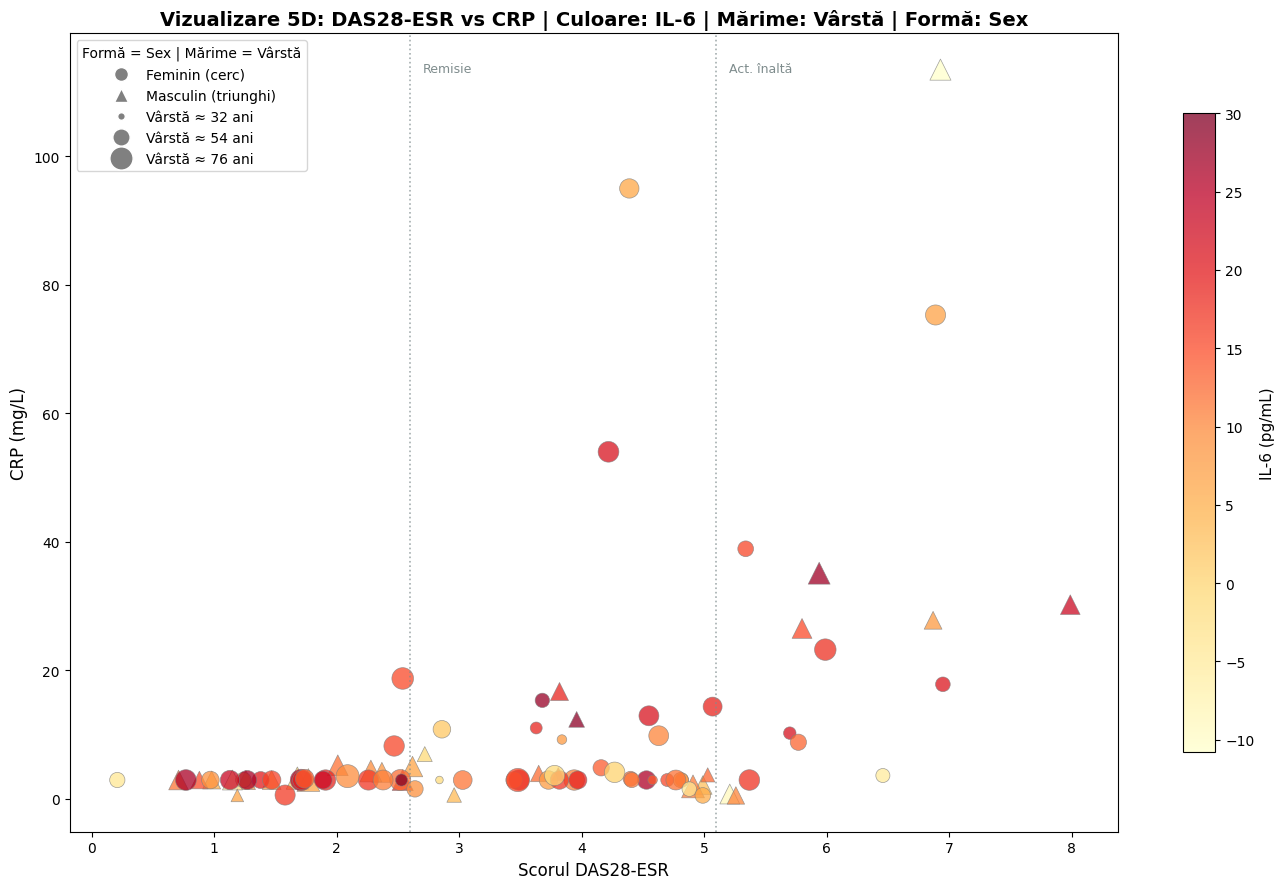

In [14]:
# 5D — Scatter: x=DAS28_ESR, y=CRP_mgL, culoare=IL6 (gradient), mărime=Varsta, formă=Sex_Feminin
# (5 variabile: DAS28_ESR, CRP_mgL, IL6_Nivel, Varsta, Sex_Feminin)
from matplotlib.lines import Line2D

subset_5d = df[["DAS28_ESR", "CRP_mgL", "IL6_Nivel", "Varsta", "Sex_Feminin"]].dropna()

age_norm_5d = (subset_5d["Varsta"] - subset_5d["Varsta"].min()) / \
              (subset_5d["Varsta"].max() - subset_5d["Varsta"].min())
sizes_5d = size_min + age_norm_5d * (size_max - size_min)

fig, ax = plt.subplots(figsize=(14, 9))

markers_sex = {0: "^", 1: "o"}  # 0=Masculin (triunghi), 1=Feminin (cerc)
sex_label_5d = {0: "Masculin (triunghi)", 1: "Feminin (cerc)"}

for sex in [0, 1]:
    mask = subset_5d["Sex_Feminin"] == sex
    sc = ax.scatter(
        subset_5d.loc[mask, "DAS28_ESR"],
        subset_5d.loc[mask, "CRP_mgL"],
        c=subset_5d.loc[mask, "IL6_Nivel"],
        cmap="YlOrRd",
        s=sizes_5d[mask],
        marker=markers_sex[sex],
        alpha=0.75, edgecolors="gray", linewidth=0.5,
        vmin=subset_5d["IL6_Nivel"].min(),
        vmax=subset_5d["IL6_Nivel"].max()
    )

cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("IL-6 (pg/mL)", fontsize=11)

legend_shape = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markersize=10, label="Feminin (cerc)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="gray",
           markersize=10, label="Masculin (triunghi)")
]
legend_size = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markersize=s ** 0.5, label=f"V\u00e2rst\u0103 \u2248 {age} ani")
    for age, s in [(32, size_min), (54, (size_min + size_max) / 2), (76, size_max)]
]

ax.legend(handles=legend_shape + legend_size, fontsize=10, loc="upper left",
          title="Form\u0103 = Sex | M\u0103rime = V\u00e2rst\u0103", title_fontsize=10)

ax.axvline(2.6, color="#7f8c8d", linewidth=1.2, linestyle=":", alpha=0.7, label="_")
ax.axvline(5.1, color="#7f8c8d", linewidth=1.2, linestyle=":", alpha=0.7, label="_")
ax.text(2.7, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 1,
        "Remisie", fontsize=9, color="#7f8c8d")
ax.text(5.2, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 1,
        "Act. \u00eenalt\u0103", fontsize=9, color="#7f8c8d")

ax.set_xlabel("Scorul DAS28-ESR", fontsize=12)
ax.set_ylabel("CRP (mg/L)", fontsize=12)
ax.set_title("Vizualizare 5D: DAS28-ESR vs CRP | Culoare: IL-6 | M\u0103rime: V\u00e2rst\u0103 | Form\u0103: Sex",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/RA_5D_scatter_DAS28_CRP_IL6_Varsta_Sex.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretare — Vizualizare 5D (DAS28-ESR, CRP, IL-6, Vârstă, Sex):**
- Cele 5 dimensiuni sunt codificate simultan: **x** = DAS28-ESR, **y** = CRP, **culoare** = IL-6 (gradient galben→roșu), **mărime** = vârstă, **formă** = sex (cerc=feminin, triunghi=masculin).
- Punctele cu culoare intensă (roșu închis, IL-6 ridicat) se concentrează în colțul dreapta-sus (DAS28 mare, CRP mare) — confirmând tripla corelație dintre cei trei markeri de inflamație sistemică în RA activă.
- Pacienții vârstnici (puncte mari) cu IL-6 ridicat și DAS28 mare reprezintă subgrupul cu cel mai mare risc de complicații sistemice și necesită monitorizare clinică intensivă.
- Pacientele feminine (cercuri) sunt mai numeroase în zona de activitate ridicată, reflectând predominanța feminină a formelor severe de RA din cohortă.
- Punctele mici și galbene (tineri, IL-6 scăzut) se distribuie în zona DAS28 < 3, sugerând că pacienții mai tineri răspund mai bine la tratament sau se prezintă cu boală mai puțin avansată.